# Template for CS5004 Task 3 --> Loading the Atari ROM
Using gym for this task as Gymnasium requires you to dowload the ROMs

Acknowledgement: Anuja Katkar, https://github.com/AnujaKatkar/OpenAI-Gym-Breakout-Env/blob/main/Notebooks/DQN_Breakout.ipynb

11 March 2025

In [ ]:
import sys
assert sys.version_info >= (3, 7)

In [ ]:
#install gym and Arcade Learning Environment (ALE)
!pip install ale_py
!pip install gym[atari,accept-rom-license]

In [ ]:
# Imports
import gym
import numpy as np
import random
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf

In [ ]:
# Import Keras
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

In [ ]:
# Breakout environment using the ALE/Breakout-v5 configuration from openAi gym
# render mode in rgb array to capture frames in rgb mode for visualisation
env = gym.make('ALE/Breakout-v5', render_mode='rgb_array')

# The ALE namespace doesn't have max steps set for Breakout, so we explicty set it to 27,000 steps, default for atari.
env.spec.max_episode_steps = 27000

# Print out some environment details
print(gym.envs.registry.keys())  # Overview over the flavors of environments that can be accessed through gym

print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)
print("Max Steps:", env.spec.max_episode_steps)
print("Reward Range:", env.reward_range)

# Set the state and action size
# state_size is the dimensions of the game's screen
# action_size is thee number actions available to the agent (Breakout offers [NOOP, FIRE, LEFT, RIGHT]
state_size = env.observation_space.shape
action_size = env.action_space.n

dict_keys(['ALE/Adventure-v5', 'ALE/Adventure-ram-v5', 'ALE/AirRaid-v5', 'ALE/AirRaid-ram-v5', 'ALE/Alien-v5', 'ALE/Alien-ram-v5', 'ALE/Amidar-v5', 'ALE/Amidar-ram-v5', 'ALE/Assault-v5', 'ALE/Assault-ram-v5', 'ALE/Asterix-v5', 'ALE/Asterix-ram-v5', 'ALE/Asteroids-v5', 'ALE/Asteroids-ram-v5', 'ALE/Atlantis-v5', 'ALE/Atlantis-ram-v5', 'ALE/Atlantis2-v5', 'ALE/Atlantis2-ram-v5', 'ALE/Backgammon-v5', 'ALE/Backgammon-ram-v5', 'ALE/BankHeist-v5', 'ALE/BankHeist-ram-v5', 'ALE/BasicMath-v5', 'ALE/BasicMath-ram-v5', 'ALE/BattleZone-v5', 'ALE/BattleZone-ram-v5', 'ALE/BeamRider-v5', 'ALE/BeamRider-ram-v5', 'ALE/Berzerk-v5', 'ALE/Berzerk-ram-v5', 'ALE/Blackjack-v5', 'ALE/Blackjack-ram-v5', 'ALE/Bowling-v5', 'ALE/Bowling-ram-v5', 'ALE/Boxing-v5', 'ALE/Boxing-ram-v5', 'ALE/Breakout-v5', 'ALE/Breakout-ram-v5', 'ALE/Carnival-v5', 'ALE/Carnival-ram-v5', 'ALE/Casino-v5', 'ALE/Casino-ram-v5', 'ALE/Centipede-v5', 'ALE/Centipede-ram-v5', 'ALE/ChopperCommand-v5', 'ALE/ChopperCommand-ram-v5', 'ALE/CrazyClimb

In [ ]:
def display_frame(state):
    """
    Metod to Visualise state of the Breakout environment from OpenAi Gym
    """
    #state = env.reset()  # Reset the environment to inital state
    if isinstance(state, tuple):
        state = state[0]
    # Plot state
    plt.imshow(state)
    plt.title("State of Breakout Environment")
    plt.axis('off')
    plt.show()

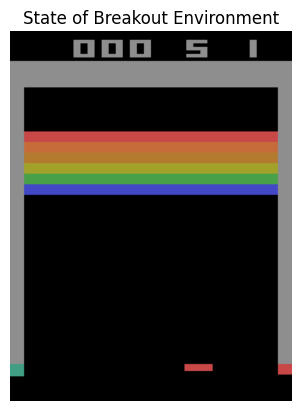

In [ ]:
display_frame(env.reset())

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


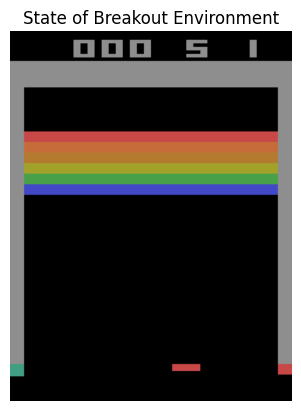

In [ ]:
next_state, reward, done, _, _ = env.step(3)
display_frame(next_state)

In [ ]:
def preprocess1(im):
      temp = im[50:-12,6:-6]
      temp = tf.image.rgb_to_grayscale(temp)
      temp = tf.image.resize(temp, [110, 84], method = tf.image.ResizeMethod.NEAREST_NEIGHBOR)
      temp = tf.cast(temp, tf.float32)
      return temp[:,:,0] / 255.0

In [ ]:
def preprocess2(im):
    im = im[31:195,:,:]  # Crop the height interval to [31:195], leaving the width unchanged
    im = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) # Convert to grayscale image
    im = cv2.resize(im, (84, 84), interpolation=cv2.INTER_AREA) # Zoom to (84, 84)
    return im / 255.0  # Standardize to [0, 1]

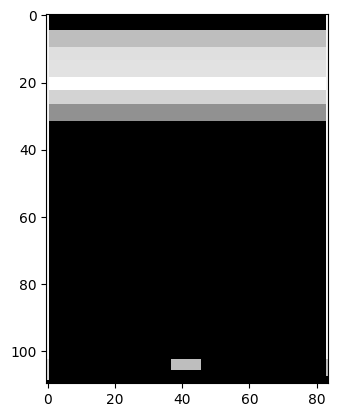

In [ ]:
next_state, reward, done, _, _ = env.step(3)
processed_state = preprocess1(next_state)
#display_frame(processed_state)
plt.imshow(processed_state,cmap = 'gray')
plt.show()

In [ ]:
def combine(im1, im2):
      if len(im1.shape) == 3 and im1.shape[0] == 4:  # checks if im1 already is a stack -->has 4 elements in the last dimension) that im2 can be appended to; dimesnions (batchsize = 1, height, width, stack size = 4) and im2 should be a single frame
        im2 = np.expand_dims(im2, 0)  # expand single frame im2 so that there is a batch size dimension
        im2 = np.expand_dims(im2, 3)  # expand single frame im2 so that there is a frame stack dimension -> necessary for appending
        im = np.append(im1[:,:,:,1:], im2, axis = 3) # im1[:, :, :, 1:] selects the three newest frames in the stack and appends im2 to it as the fourth
        return im
      else:  # if the first parameter is a single frame (which is the case for the first frame ever passed), this copies this single frame to produce a frame stack -> we don't want this to happen if we got beyond the first frame, so that temporal information are actually contained in the frame stack
        im = np.stack([im1]*4, axis = 2)  # appends 4 copies of im1 together
        return tf.expand_dims(im, 0)  # adds batch size dimension


In [ ]:
def act(state):
  #if np.random.rand() <= self.epsilon:
    return np.random.randint(action_size)
  #q_values = self.model.predict(state, verbose = 0)
  #return np.argmax(q_values[0])

(1, 110, 84, 4)


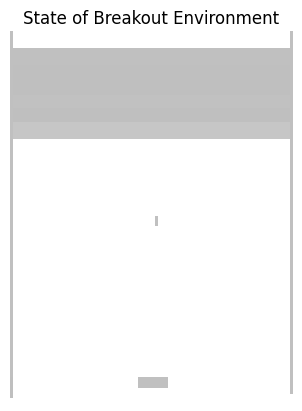

In [ ]:
# example of using preprocess and combine to create stacked frames
# moce this into the training loop
# store stacked frames in replay buffer
# sample stacked frames from replay buffer
state, info = env.reset()
state = preprocess1(state)
action = act(state)
nextState, reward, done, _, _ = env.step(action)
nextState= preprocess2(nextState)
nextState = combine(nextState, state)

action = act(nextState)
state = nextState
nextState, reward, done, _, _ = env.step(action)
nextState= preprocess1(nextState)
nextState = combine(nextState, state)

print(nextState.get_shape())
display_frame(nextState[-0])


In [ ]:
def build_model():
  model = Sequential()
  model.add(Conv2D(32, 8, (4,4), activation = 'relu', padding = 'valid', input_shape = state_size)) # TODO: maybe use elu
  model.add(Conv2D(64, 4, (2,2), activation = 'relu', padding = 'valid'))
  model.add(MaxPooling2D())
  model.add(Conv2D(64, 3, (1,1), activation = 'relu', padding = 'valid'))
  model.add(MaxPooling2D())
  model.add(Flatten())
  model.add(Dense(256, activation='relu'))
  model.add(Dense(action_size, activation='linear'))
  model.compile(optimizer=Adam(), loss=MeanSquaredError())
  model.summary()
  return model

In [ ]:
model = build_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 51, 39, 32)          │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 18, 64)          │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 9, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 7, 64)           │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 960)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         246,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,980 (1.23 MB)

 Trainable params: 322,980 (1.23 MB)

 Non-trainable params: 0 (0.00 B)